<a href="https://colab.research.google.com/github/Shqcod/BananaRipenessClassification/blob/main/classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shahriar26s/banana-ripeness-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'banana-ripeness-classification-dataset' dataset.
Path to dataset files: /kaggle/input/banana-ripeness-classification-dataset


In [ ]:
!ls /root/.cache/kagglehub/datasets/shahriar26s/banana-ripeness-classification-dataset/versions/1/'Banana Ripeness Classification Dataset'

test  train  valid


In [ ]:
import os

# Correct the dataset_path to point to the actual data directory
corrected_dataset_path = os.path.join(path, 'Banana Ripeness Classification Dataset')

print(f"Corrected dataset path: {corrected_dataset_path}")
print(f"Contents of the corrected dataset directory '{corrected_dataset_path}':")
for item in os.listdir(corrected_dataset_path):
    item_path = os.path.join(corrected_dataset_path, item)
    if os.path.isdir(item_path):
        print(f"  [DIR] {item}")
    else:
        print(f"  [FILE] {item}")

Corrected dataset path: /kaggle/input/banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset
Contents of the corrected dataset directory '/kaggle/input/banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset':
  [DIR] valid
  [DIR] test
  [DIR] train


### Distribusi Label

Aggregated Image counts per ripeness label:
      Label  Count
0    unripe   2179
1  overripe   2691
2    rotten   4593
3      ripe   4015


/tmp/ipykernel_951/1470683845.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label', y='Count', data=df_counts_corrected, palette='viridis')


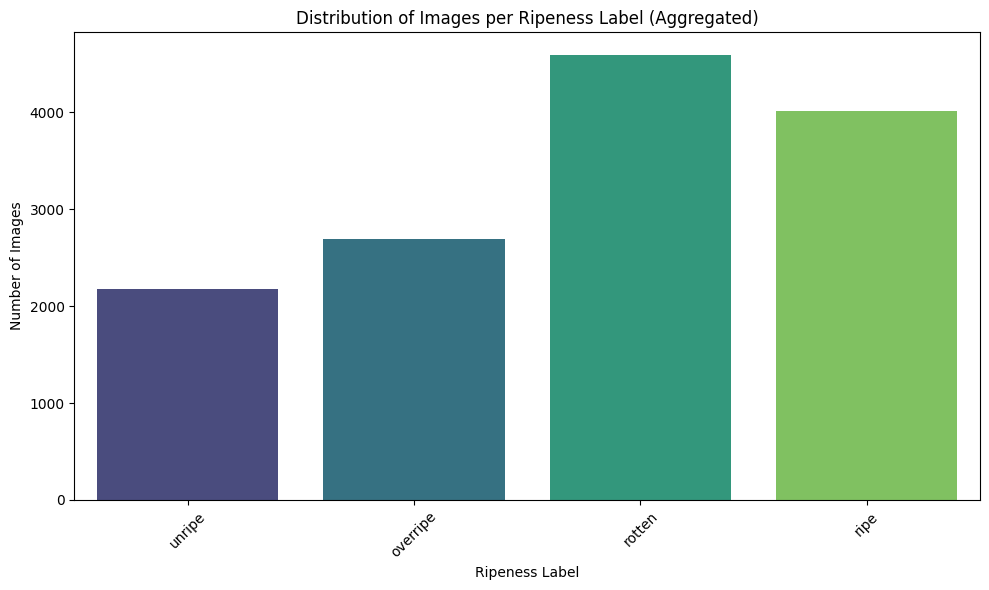

In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

image_counts_per_label = {}

# Iterate through 'train', 'test', 'valid' subdirectories
for split_folder in ['train', 'test', 'valid']:
    split_path = os.path.join(corrected_dataset_path, split_folder)
    if not os.path.isdir(split_path):
        print(f"Warning: {split_path} not found. Skipping.")
        continue

    # Each subfolder in split_path is a label (e.g., 'Ripe', 'Unripe')
    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if os.path.isdir(label_path):
            # Count image files (e.g., .jpg, .jpeg, .png)
            count = len(glob.glob(os.path.join(label_path, '*.jpg'))) + \
                    len(glob.glob(os.path.join(label_path, '*.jpeg'))) + \
                    len(glob.glob(os.path.join(label_path, '*.png')))

            # Aggregate counts for each label across all splits
            image_counts_per_label[label] = image_counts_per_label.get(label, 0) + count

# Create a DataFrame for easier plotting
df_counts_corrected = pd.DataFrame(image_counts_per_label.items(), columns=['Label', 'Count'])

print("Aggregated Image counts per ripeness label:")
print(df_counts_corrected)

# Visualize the distribution
fig_dist = plt.figure(figsize=(10, 6))
sns.barplot(x='Label', y='Count', data=df_counts_corrected, palette='viridis')
plt.title('Distribution of Images per Ripeness Label (Aggregated)')
plt.xlabel('Ripeness Label')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Menampilkan gambar sampel tiap label

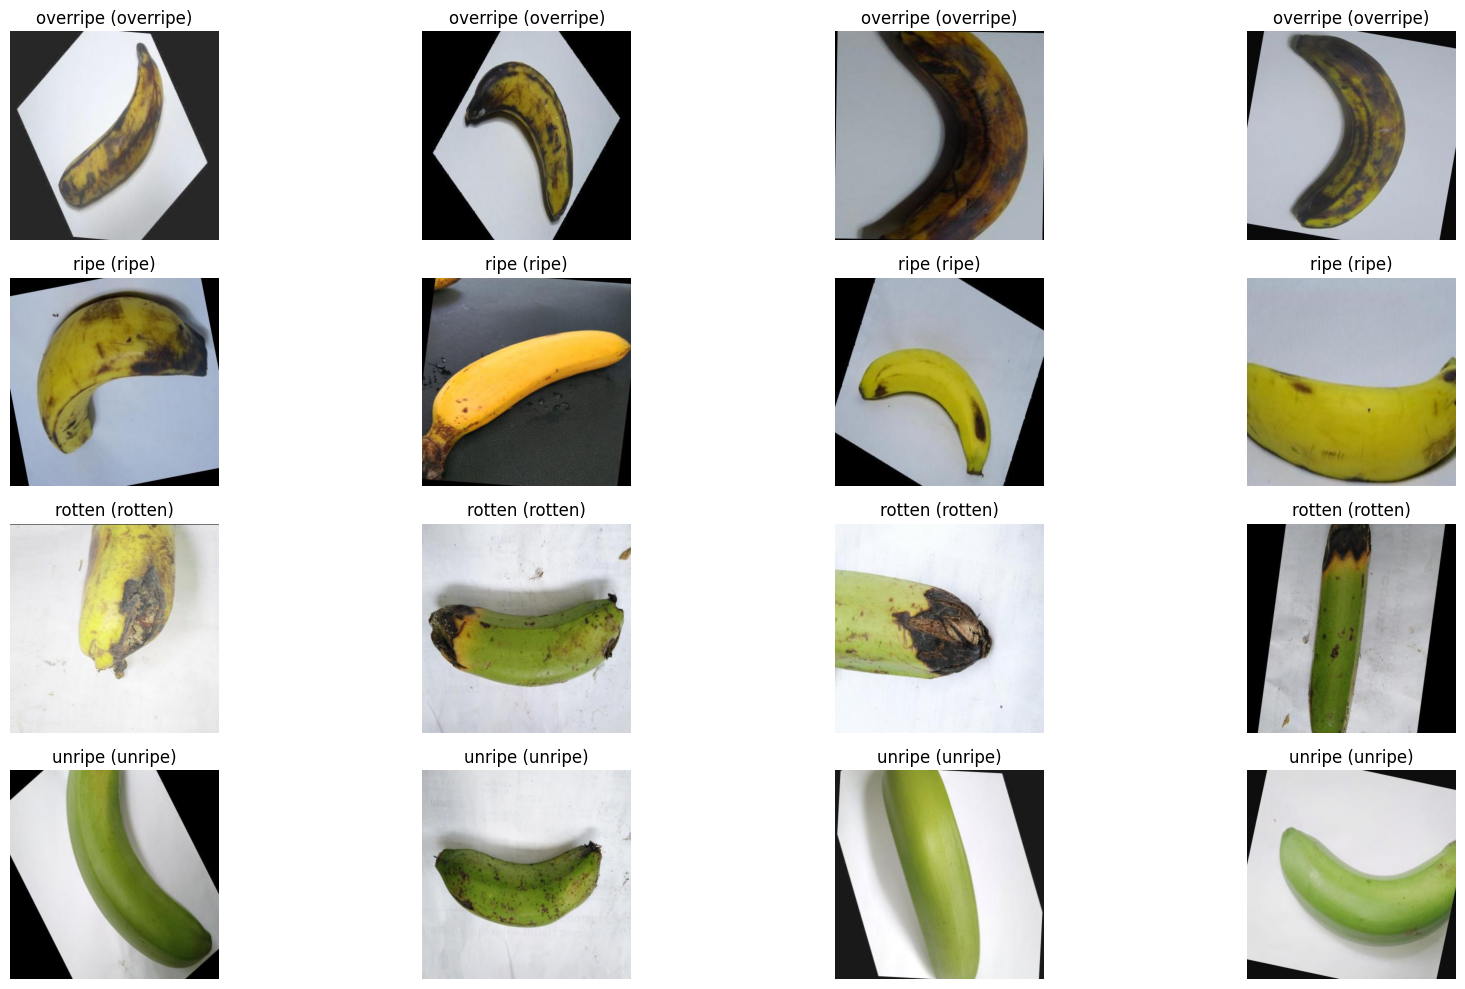

In [ ]:
import random

plt.figure(figsize=(18, 10))

sample_images_per_label = 4 # Number of images to display per label

all_labels = sorted(list(image_counts_per_label.keys()))

for i, label in enumerate(all_labels):
    # Collect image paths for the current label from all splits
    all_image_paths_for_label = []
    for split_folder in ['train', 'test', 'valid']:
        split_label_path = os.path.join(corrected_dataset_path, split_folder, label)
        if os.path.isdir(split_label_path):
            all_image_paths_for_label.extend(glob.glob(os.path.join(split_label_path, '*.jpg')))
            all_image_paths_for_label.extend(glob.glob(os.path.join(split_label_path, '*.jpeg')))
            all_image_paths_for_label.extend(glob.glob(os.path.join(split_label_path, '*.png')))

    # Select random images from the collected paths
    selected_images = random.sample(all_image_paths_for_label, min(len(all_image_paths_for_label), sample_images_per_label))

    for j, img_path in enumerate(selected_images):
        plt.subplot(len(all_labels), sample_images_per_label, i * sample_images_per_label + j + 1)
        try:
            img = Image.open(img_path)
            plt.imshow(img)
            plt.title(f"{label} ({os.path.basename(os.path.dirname(img_path))})") # Show label and split (train/test/valid)
            plt.axis('off')
        except Exception as e:
            print(f"Could not load image {img_path}: {e}")
            plt.axis('off')

plt.tight_layout()
plt.show()

### Distribusi Ukuran

### Menggunakan ResNet18 Pretrained untuk Klasifikasi Kematangan

ResNet18 adalah arsitektur jaringan saraf konvolusional yang populer. Dengan menggunakan versi yang telah dilatih sebelumnya di ImageNet, kita dapat memanfaatkan fitur yang telah dipelajari untuk tugas klasifikasi kematangan pisang kita. Kita akan menyesuaikan lapisan terakhirnya untuk memprediksi kategori kematangan spesifik kita.

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

# Load a pre-trained ResNet18 model
model_resnet = models.resnet18(pretrained=True)

# Freeze all parameters in the network
for param in model_resnet.parameters():
    param.requires_grad = False

# Get the number of input features for the last layer
num_ftrs = model_resnet.fc.in_features

# Replace the final fully connected layer to match our number of classes
# The 'all_labels' list contains our ripeness categories.
num_classes = len(all_labels)
model_resnet.fc = nn.Linear(num_ftrs, num_classes)

# Set the model to evaluation mode (important for inference)
model_resnet.eval()

print(f"Pretrained ResNet18 loaded and its final layer adapted for {num_classes} classes.")

Pretrained ResNet18 loaded and its final layer adapted for 4 classes.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Transformasi Gambar

Untuk prapemrosesan gambar, transformasi standar untuk model yang dilatih di ImageNet diterapkan:
*   **Ubah Ukuran (Resize):** Gambar diubah ukurannya menjadi 256x256 piksel.
*   **Pangkas Tengah (CenterCrop):** Bagian tengah gambar dipangkas menjadi 224x224 piksel, yang merupakan ukuran input yang diharapkan oleh ResNet.
*   **Konversi ke Tensor:** Gambar dikonversi dari format PIL Image atau NumPy array ke PyTorch Tensor.
*   **Normalisasi:** Gambar dinormalisasi menggunakan nilai rata-rata (`mean=[0.485, 0.456, 0.406]`) dan standar deviasi (`std=[0.229, 0.224, 0.225]`) dari dataset ImageNet.

In [ ]:
# Define image transformations for ResNet
# These transformations are standard for ImageNet-trained models
transform = transforms.Compose([
    transforms.Resize(256),         # Resize the image to 256x256
    transforms.CenterCrop(224),     # Crop the center to 224x224 (ResNet's expected input size)
    transforms.ToTensor(),          # Convert PIL Image or NumPy array to PyTorch Tensor
    transforms.Normalize(           # Normalize with ImageNet's mean and standard deviation
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformation pipeline defined.")

Image transformation pipeline defined.


### Pelatihan Model

Hyperparameter yang digunakan selama pelatihan model adalah:
*   **Ukuran Batch (Batch Size):** 32
*   **Optimizer:** Adam
*   **Tingkat Pembelajaran (Learning Rate):** 0.001 (khusus untuk lapisan `fc` yang tidak dibekukan).
*   **Fungsi Kerugian (Loss Function):** `nn.CrossEntropyLoss` (untuk masalah klasifikasi multi-kelas).
*   **Jumlah Epoch:** 10

In [ ]:
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# Dataset & DataLoader
train_dataset = ImageFolder(root=os.path.join(corrected_dataset_path, 'train'), transform=transform)
val_dataset = ImageFolder(root=os.path.join(corrected_dataset_path, 'valid'), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
from torch.optim import Adam

# Dataset & DataLoader
train_dataset = ImageFolder(root=os.path.join(corrected_dataset_path, 'train'), transform=transform)
val_dataset = ImageFolder(root=os.path.join(corrected_dataset_path, 'valid'), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Unfreeze fc layer saja (sudah difreeze semua di cell sebelumnya)
for param in model_resnet.fc.parameters():
    param.requires_grad = True

# Loss & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model_resnet.fc.parameters(), lr=0.001)

# Training loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_resnet.to(device)

num_epochs = 10

for epoch in range(num_epochs):
    model_resnet.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # Validation
    model_resnet.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch [1/10] Loss: 0.3226 | Train Acc: 0.9012 | Val Acc: 0.9484
Epoch [2/10] Loss: 0.1804 | Train Acc: 0.9424 | Val Acc: 0.9617
Epoch [3/10] Loss: 0.1546 | Train Acc: 0.9472 | Val Acc: 0.9626
Epoch [4/10] Loss: 0.1431 | Train Acc: 0.9517 | Val Acc: 0.9608
Epoch [5/10] Loss: 0.1332 | Train Acc: 0.9539 | Val Acc: 0.9635
Epoch [6/10] Loss: 0.1211 | Train Acc: 0.9574 | Val Acc: 0.9679
Epoch [7/10] Loss: 0.1230 | Train Acc: 0.9566 | Val Acc: 0.9644
Epoch [8/10] Loss: 0.1216 | Train Acc: 0.9568 | Val Acc: 0.9679
Epoch [9/10] Loss: 0.1162 | Train Acc: 0.9596 | Val Acc: 0.9706
Epoch [10/10] Loss: 0.1116 | Train Acc: 0.9607 | Val Acc: 0.9688


### Evaluasi

Evaluasi model dilakukan pada dataset pengujian (test set) setelah pelatihan. Metrik dan visualisasi yang digunakan meliputi:
*   **Matriks Kebingungan (Confusion Matrix):** Sebuah visualisasi yang menunjukkan jumlah prediksi benar dan salah untuk setiap kelas. Ini membantu dalam memahami di mana model membuat kesalahan.
*   **Laporan Klasifikasi (Classification Report):** Menyediakan metrik-metrik utama seperti:
    *   **Presisi (Precision):** Kemampuan model untuk tidak melabeli instance negatif sebagai positif.
    *   **Recall:** Kemampuan model untuk menemukan semua instance positif.
    *   **F1-Score:** Rata-rata harmonis dari presisi dan recall.
    *   **Dukungan (Support):** Jumlah sebenarnya dari setiap kelas dalam dataset pengujian.
    *   **Akurasi (Accuracy):** Proporsi total prediksi yang benar.

Dari laporan klasifikasi terakhir, model mencapai akurasi keseluruhan sekitar 0.96 (96%) pada dataset pengujian.

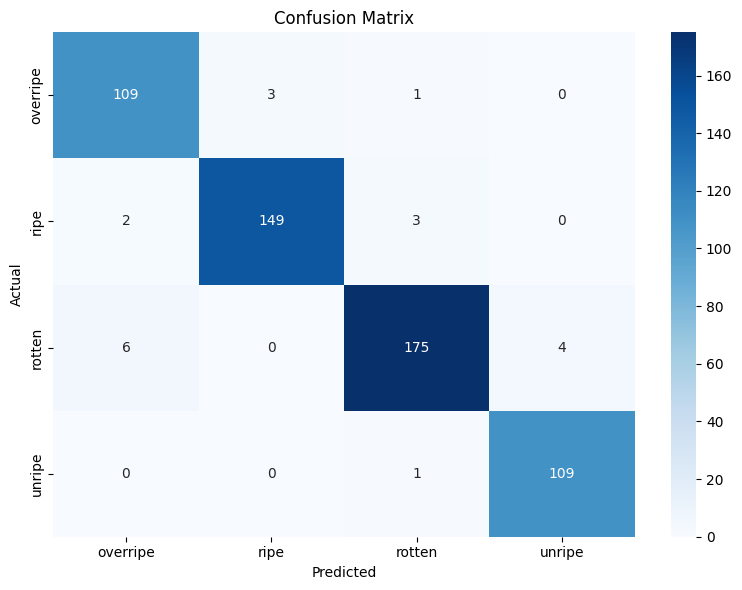

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

test_dataset = ImageFolder(root=os.path.join(corrected_dataset_path, 'test'), transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

idx_to_label = {v: k for k, v in test_dataset.class_to_idx.items()}
class_names = [idx_to_label[i] for i in range(len(idx_to_label))]

all_preds = []
all_true = []

model_resnet.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_true, all_preds, target_names=class_names))

              precision    recall  f1-score   support

    overripe       0.93      0.96      0.95       113
        ripe       0.98      0.97      0.97       154
      rotten       0.97      0.95      0.96       185
      unripe       0.96      0.99      0.98       110

    accuracy                           0.96       562
   macro avg       0.96      0.97      0.96       562
weighted avg       0.96      0.96      0.96       562



### Prediksi pada Gambar Sampel

<Figure size 2000x500 with 0 Axes>

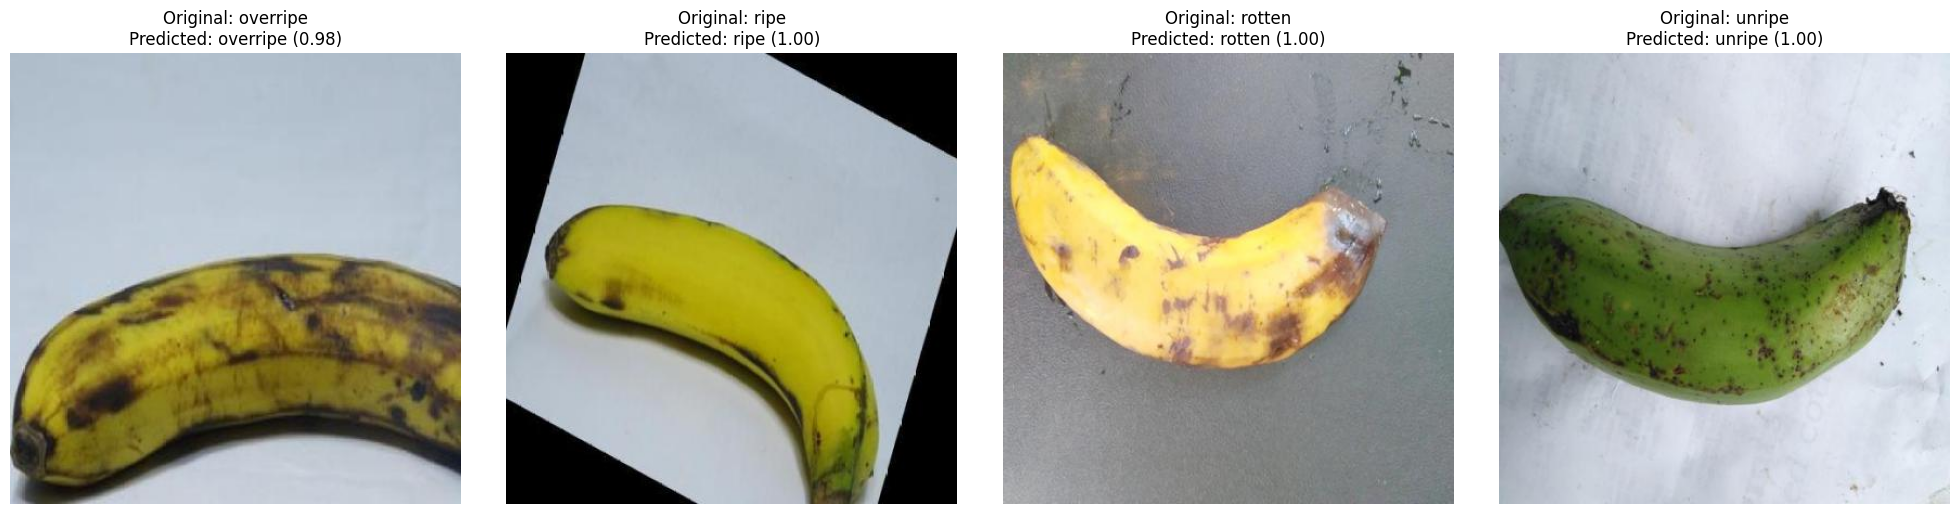

ResNet18 inference complete for sample images.


In [ ]:
plt.figure(figsize=(20, 5))
idx_to_label = {v: k for k, v in train_dataset.class_to_idx.items()}

all_sample_images = []
for label in all_labels:
    for split_folder in ['test']:
        label_path = os.path.join(corrected_dataset_path, split_folder, label)
        if os.path.isdir(label_path):
            paths = glob.glob(os.path.join(label_path, '*.jpg'))
            paths += glob.glob(os.path.join(label_path, '*.jpeg'))
            paths += glob.glob(os.path.join(label_path, '*.png'))
            if paths:
                all_sample_images.append(random.choice(paths))

plt.figure(figsize=(20, 5))
with torch.no_grad():
    for i, img_path in enumerate(all_sample_images):
        try:
            img_pil = Image.open(img_path).convert('RGB') # Ensure image is RGB

            # Preprocess the image
            img_tensor = transform(img_pil)
            img_tensor = img_tensor.unsqueeze(0) # Add a batch dimension (B, C, H, W)

            # Make a prediction
            output = model_resnet(img_tensor)
            probabilities = torch.softmax(output, dim=1)[0] # Convert logits to probabilities
            predicted_class_idx = torch.argmax(probabilities).item()
            predicted_label = idx_to_label[predicted_class_idx]
            confidence = probabilities[predicted_class_idx].item()

            # Plotting
            plt.subplot(1, len(selected_images), i + 1)
            plt.imshow(img_pil) # Display the original PIL image
            original_label = os.path.basename(os.path.dirname(img_path))
            plt.title(f"Original: {original_label}\nPredicted: {predicted_label} ({confidence:.2f})")
            plt.axis('off')

        except Exception as e:
            print(f"Could not process image {img_path} for ResNet: {e}")
            plt.axis('off')

plt.tight_layout()
plt.show()

print("ResNet18 inference complete for sample images.")

### Simpan Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

torch.save(model_resnet.state_dict(), '/content/drive/MyDrive/Kuliah/semester6/ML/banana_ripeness_resnet18.pt')
print("Model saved to Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to Google Drive


## Perbandingan dengan Model MobileNetV2 (Lebih Ringan)

### Prasyarat MobileNetV2
Cell ini mempersiapkan variabel yang diperlukan (loaders & device) tanpa menjalankan proses training ResNet18 kembali.

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Setup DataLoader ulang
train_dataset = ImageFolder(root=os.path.join(corrected_dataset_path, 'train'), transform=transform)
val_dataset = ImageFolder(root=os.path.join(corrected_dataset_path, 'valid'), transform=transform)
test_dataset = ImageFolder(root=os.path.join(corrected_dataset_path, 'test'), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Ambil class names untuk evaluasi nanti
idx_to_label = {v: k for k, v in train_dataset.class_to_idx.items()}
class_names = [idx_to_label[i] for i in range(len(idx_to_label))]
num_classes = len(class_names)

print(f"Siap untuk training MobileNetV2 dengan {num_classes} kelas menggunakan {device}.")

Siap untuk training MobileNetV2 dengan 4 kelas menggunakan cuda.


In [ ]:
import torch.nn as nn
import torchvision.models as models
from torch.optim import Adam


In [ ]:
# 1. Load Pretrained MobileNetV2
model_mobile = models.mobilenet_v2(pretrained=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 216MB/s]


In [ ]:
# 2. Freeze feature extractor (membekukan seluruh parameter awal)
for param in model_mobile.parameters():
    param.requires_grad = False

In [ ]:
# 3. Adaptasi Classifier Layer
num_ftrs_mobile = model_mobile.classifier[1].in_features
model_mobile.classifier[1] = nn.Linear(num_ftrs_mobile, num_classes)

In [ ]:
# 4. Pindahkan ke Device (GPU/CPU)
model_mobile.to(device)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
# 5. Loss & Optimizer (Gunakan hyperparameter yang sama dengan baseline)
criterion_mobile = nn.CrossEntropyLoss()
optimizer_mobile = Adam(model_mobile.classifier.parameters(), lr=0.001)

print(f"MobileNetV2 loaded.")
print(f"Input features to classifier: {num_ftrs_mobile}")
print(f"Total parameter jauh lebih kecil, proses training akan terasa lebih ringan.")

MobileNetV2 loaded.
Input features to classifier: 1280
Total parameter jauh lebih kecil, proses training akan terasa lebih ringan.


### Training Loop MobileNetV2

In [ ]:
num_epochs = 10
history_mobile = {'train_acc': [], 'val_acc': [], 'loss': []}

for epoch in range(num_epochs):
    model_mobile.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_mobile.zero_grad()
        outputs = model_mobile(images)
        loss = criterion_mobile(outputs, labels)
        loss.backward()
        optimizer_mobile.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # Validation Phase
    model_mobile.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_mobile(images)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    # Simpan history
    history_mobile['train_acc'].append(train_acc)
    history_mobile['val_acc'].append(val_acc)
    history_mobile['loss'].append(running_loss/len(train_loader))

    print(f"MobileNetV2 - Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

MobileNetV2 - Epoch [1/10] Loss: 0.2813 | Train Acc: 0.9092 | Val Acc: 0.9564
MobileNetV2 - Epoch [2/10] Loss: 0.1635 | Train Acc: 0.9453 | Val Acc: 0.9546
MobileNetV2 - Epoch [3/10] Loss: 0.1383 | Train Acc: 0.9528 | Val Acc: 0.9662
MobileNetV2 - Epoch [4/10] Loss: 0.1332 | Train Acc: 0.9523 | Val Acc: 0.9724
MobileNetV2 - Epoch [5/10] Loss: 0.1244 | Train Acc: 0.9552 | Val Acc: 0.9760
MobileNetV2 - Epoch [6/10] Loss: 0.1207 | Train Acc: 0.9579 | Val Acc: 0.9724
MobileNetV2 - Epoch [7/10] Loss: 0.1161 | Train Acc: 0.9600 | Val Acc: 0.9742
MobileNetV2 - Epoch [8/10] Loss: 0.1100 | Train Acc: 0.9604 | Val Acc: 0.9715
MobileNetV2 - Epoch [9/10] Loss: 0.1147 | Train Acc: 0.9593 | Val Acc: 0.9760
MobileNetV2 - Epoch [10/10] Loss: 0.1118 | Train Acc: 0.9586 | Val Acc: 0.9751


### Evaluasi Akhir MobileNetV2

In [ ]:
from sklearn.metrics import classification_report

all_preds_mobile = []
all_true_mobile = []

model_mobile.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_mobile(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_mobile.extend(predicted.cpu().numpy())
        all_true_mobile.extend(labels.cpu().numpy())

print("--- Classification Report: MobileNetV2 ---")
print(classification_report(all_true_mobile, all_preds_mobile, target_names=class_names))

--- Classification Report: MobileNetV2 ---
              precision    recall  f1-score   support

    overripe       0.98      0.92      0.95       113
        ripe       0.92      0.97      0.95       154
      rotten       0.95      0.95      0.95       185
      unripe       0.98      0.96      0.97       110

    accuracy                           0.95       562
   macro avg       0.96      0.95      0.95       562
weighted avg       0.95      0.95      0.95       562



```markdown
## Visualisasi Perbandingan ResNet18 vs MobileNetV2
Bagian ini merangkum performa kedua model untuk melihat mana yang lebih efisien dan akurat.
```

,Model,Validation Accuracy,Parameters (Approx),Status
0,ResNet18,0.960000,11 Million,Heavyweight
1,MobileNetV2,0.975067,2.2 Million,Lightweight/Mobile


/tmp/ipykernel_951/2525587261.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Validation Accuracy', data=df_compare, palette='Set2')


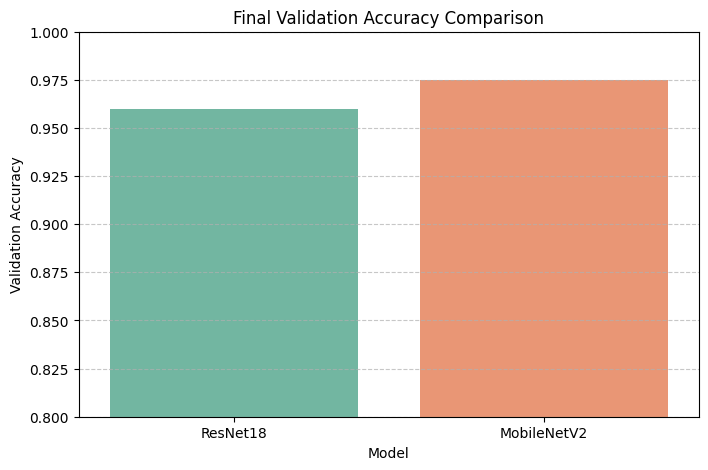

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Persiapan Data Perbandingan
# Akurasi ResNet18 diambil dari variabel terakhir
# Karena training menggunakan ResNet18 sangat lama jika di train kembali (3 jam lebih)
# Akurasi MobileNetV2 diambil dari history_mobile
resnet_final_acc = 0.96
mobile_final_acc = history_mobile['val_acc'][-1]

comparison_data = {
    'Model': ['ResNet18', 'MobileNetV2'],
    'Validation Accuracy': [resnet_final_acc, mobile_final_acc],
    'Parameters (Approx)': ['11 Million', '2.2 Million'],
    'Status': ['Heavyweight', 'Lightweight/Mobile']
}

df_compare = pd.DataFrame(comparison_data)
display(df_compare)

# 2. Plot Perbandingan Akurasi
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Validation Accuracy', data=df_compare, palette='Set2')
plt.ylim(0.8, 1.0)
plt.title('Final Validation Accuracy Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Hasil akhir memiliki akurasi yang nyaris seimbang meskipun disini MobileNetV2 sedikit lebih tinggi dibanding ResNet18. ResNet18 sendiri memiliki 11 Juta Parameter sedangkan MobileNetV2 hanya memiliki 2 Juta Parameter. Dengan hasil yang mirip , MobileNetV2 lebih unggul dibanding ResNet18 yang memakan lama waktu.